# Week 7 Progress — Fourier Neural Operator on 1D Burgers' Equation
## Track D: Neural Operators

> **Checkpoint goal:** Train an FNO mapping `u₀(x) → u(x,T=1)` with test L² error < 5%.

| Approach | Learns | Input → Output |
|---|---|---|
| PINN (Weeks 1–5) | One solution for one IC | `(x,t) → u` |
| Neural Operator (this project) | The solution *map* for all ICs | `u₀(x) → u(x,T)` |

FNO implemented from scratch in PyTorch — no external `neuraloperator` library.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Using device: cuda
PyTorch: 2.12.1+cu126


---
## Step 1 — Data Generation

### Solver: Pseudo-spectral RK4 with Integrating Factor

**Why not `solve_ivp`?**
Burgers' in Fourier space is stiff — the diffusion term `−ν k² û` has large coefficients
for high wavenumbers, forcing tiny timesteps. `solve_ivp` also can't handle complex state
vectors natively, causing silent failures.

**Fix:** Apply an integrating factor `E = exp(−ν k² dt)` that absorbs the stiff linear
diffusion term *analytically*, leaving only the mild nonlinear advection for RK4.
Add 2/3 dealiasing (Orszag rule) to prevent aliasing errors from the nonlinear term.
No `solve_ivp` needed — direct timestepping is fast and stable.


In [2]:
def sample_grf_ic(x_grid, n_samples, length_scale=0.3, amplitude=1.0, seed=None):
    """
    Sample smooth random initial conditions from a Gaussian Random Field
    via truncated Fourier series. Amplitudes normalised to max |u0| ≤ 1
    to prevent timestepper blowup on high-amplitude samples.
    """
    rng = np.random.RandomState(seed)
    N, n_modes = len(x_grid), 20
    ics = np.zeros((n_samples, N))
    for i in range(n_samples):
        coeffs = rng.normal(0, 1, n_modes) * amplitude
        phases = rng.uniform(0, 2 * np.pi, n_modes)
        u0 = np.zeros(N)
        for m in range(1, n_modes + 1):
            decay = np.exp(-length_scale * m)   # smooth: high modes decay fast
            u0 += coeffs[m-1] * decay * np.sin(m * np.pi * x_grid + phases[m-1])
        ics[i] = u0
        # Normalise amplitude to [-1, 1] — prevents RK4 blowup on rare large samples
        mx = np.max(np.abs(ics[i]))
        if mx > 1.0:
            ics[i] /= mx
    return ics


def burgers_solve_single(x_grid, u0, T=1.0, nu=0.01/np.pi, N_spec=256, n_steps=1000):
    """
    Solve Burgers' equation for ONE initial condition via:
      - Pseudo-spectral discretisation (N_spec Fourier modes)
      - RK4 timestepping with integrating factor (handles stiffness, no solve_ivp needed)
      - 2/3 dealiasing (Orszag rule) to suppress aliasing from the nonlinear term

    Returns u(x, T) interpolated onto x_grid.
    """
    # Spectral computation grid (periodic, N_spec points)
    x_spec = np.linspace(-1, 1, N_spec, endpoint=False)
    k      = np.fft.fftfreq(N_spec, d=(x_spec[1] - x_spec[0]) / (2 * np.pi))
    k2     = k**2

    # 2/3 dealiasing mask: zero top third of Fourier modes
    dealias = np.ones(N_spec)
    dealias[N_spec // 3 : 2 * N_spec // 3] = 0.0

    # Interpolate IC onto spectral grid and take FFT
    u_hat = fft(np.interp(x_spec, x_grid, u0)) * dealias

    dt = T / n_steps

    def N_hat(uh):
        """Nonlinear term: FFT(-u * u_x) with dealiasing."""
        u   = np.real(ifft(uh))
        u_x = np.real(ifft(1j * k * uh))
        return fft(-u * u_x) * dealias

    # RK4 with integrating factor:
    #   E  = exp(-nu*k2*dt)   — exact diffusion over one full step
    #   Eh = exp(-nu*k2*dt/2) — exact diffusion over half step
    for _ in range(n_steps):
        E  = np.exp(-nu * k2 * dt)
        Eh = np.exp(-nu * k2 * dt / 2)

        N1 = N_hat(u_hat)
        N2 = N_hat(Eh * u_hat + (dt / 2) * Eh * N1)
        N3 = N_hat(Eh * u_hat + (dt / 2) * Eh * N2)
        N4 = N_hat(E  * u_hat +  dt      * E  * N3)

        u_hat = (E * u_hat
                 + (dt / 6) * (E * N1 + 2 * Eh * N2 + 2 * Eh * N3 + N4))

    uT_spec = np.real(ifft(u_hat))
    return np.interp(x_grid, x_spec, uT_spec)


print("Data generation functions defined ✓")
print("Solver: pseudo-spectral RK4 with integrating factor + 2/3 dealiasing")

Data generation functions defined ✓
Solver: pseudo-spectral RK4 with integrating factor + 2/3 dealiasing


In [3]:
# Generate training and test datasets
N_x    = 128
x_grid = np.linspace(-1, 1, N_x)
nu_fixed = 0.01 / np.pi

N_train, N_test = 1000, 200
print(f"Generating {N_train} training + {N_test} test trajectories...")
print("(~2–3 min on CPU with n_steps=1000)")

u0_train = sample_grf_ic(x_grid, N_train, seed=1)
u0_test  = sample_grf_ic(x_grid, N_test,  seed=2)

uT_train = np.zeros_like(u0_train)
for i in range(N_train):
    uT_train[i] = burgers_solve_single(x_grid, u0_train[i], nu=nu_fixed)
    if (i + 1) % 200 == 0:
        print(f"  Train: {i+1}/{N_train}")

uT_test = np.zeros_like(u0_test)
for i in range(N_test):
    uT_test[i] = burgers_solve_single(x_grid, u0_test[i], nu=nu_fixed)

# Safety check: no NaN in the dataset
n_nan_train = np.sum(np.isnan(uT_train))
n_nan_test  = np.sum(np.isnan(uT_test))
print(f"\nDataset complete ✓ | NaN in train: {n_nan_train} | NaN in test: {n_nan_test}")
print(f"u0_train: {u0_train.shape},  uT_train: {uT_train.shape}")

Generating 1000 training + 200 test trajectories...
(~2–3 min on CPU with n_steps=1000)
  Train: 200/1000
  Train: 400/1000
  Train: 600/1000
  Train: 800/1000
  Train: 1000/1000

Dataset complete ✓ | NaN in train: 0 | NaN in test: 0
u0_train: (1000, 128),  uT_train: (1000, 128)


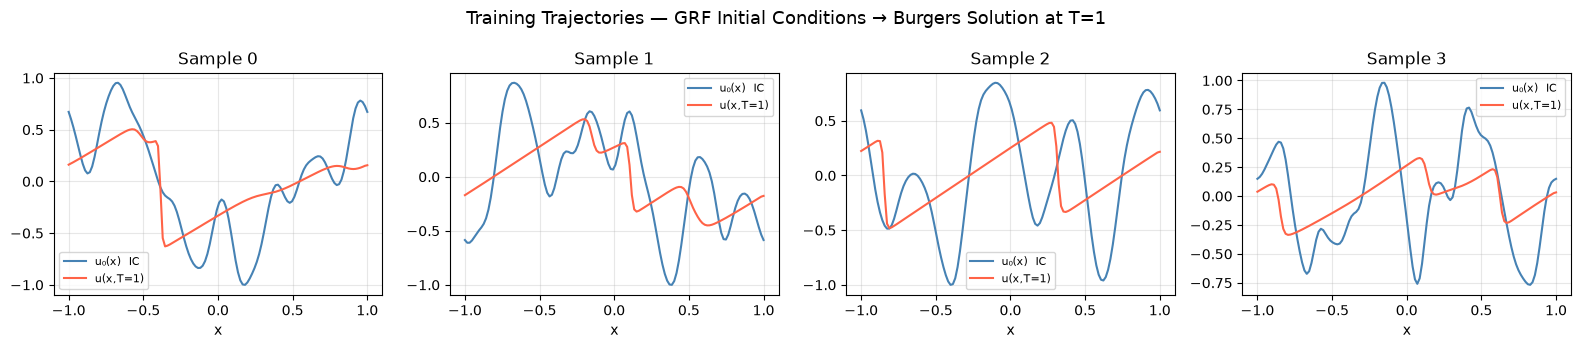

In [4]:
# Plot a few sample trajectories to sanity-check
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for i, ax in enumerate(axes):
    ax.plot(x_grid, u0_train[i], label="u₀(x)  IC", color="steelblue", lw=1.5)
    ax.plot(x_grid, uT_train[i], label="u(x,T=1)", color="tomato",    lw=1.5)
    ax.set_title(f"Sample {i}", fontsize=12)
    ax.set_xlabel("x")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Training Trajectories — GRF Initial Conditions → Burgers Solution at T=1",
             fontsize=13)
plt.tight_layout()
plt.savefig("week7_sample_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 2 — Fourier Neural Operator Architecture

```
u₀(x) ─► Lift (u₀, x) → hidden ─► [SpectralConv1d + Local Conv1×1 + GELU] × 4 ─► Project → u(x,T)
```

Each **SpectralConv1d** layer:
1. `rfft` → complex Fourier coefficients
2. Truncate to `k_modes` lowest frequencies
3. Multiply by a learned complex weight matrix (per frequency)
4. `irfft` back to physical space


In [5]:
class SpectralConv1d(nn.Module):
    """1D Fourier layer: rfft → learned complex weights on k_modes → irfft."""
    def __init__(self, in_channels, out_channels, k_modes):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.k_modes = k_modes

        scale = 1.0 / (in_channels * out_channels)
        self.weights_real = nn.Parameter(scale * torch.randn(in_channels, out_channels, k_modes))
        self.weights_imag = nn.Parameter(scale * torch.randn(in_channels, out_channels, k_modes))

    def compl_mul1d(self, xr, xi, wr, wi):
        """Complex multiply: (a+bi)(c+di) = (ac−bd) + (ad+bc)i via real einsum."""
        return (torch.einsum("bix,iox->box", xr, wr) - torch.einsum("bix,iox->box", xi, wi),
                torch.einsum("bix,iox->box", xr, wi) + torch.einsum("bix,iox->box", xi, wr))

    def forward(self, x):
        B, _, N = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)           # (B, C_in, N//2+1)
        modes = min(self.k_modes, N // 2 + 1)

        out_r = torch.zeros(B, self.out_channels, N // 2 + 1, device=x.device)
        out_i = torch.zeros(B, self.out_channels, N // 2 + 1, device=x.device)
        r, im = self.compl_mul1d(
            x_ft.real[:, :, :modes], x_ft.imag[:, :, :modes],
            self.weights_real[:, :, :modes], self.weights_imag[:, :, :modes]
        )
        out_r[:, :, :modes] = r
        out_i[:, :, :modes] = im

        return torch.fft.irfft(torch.complex(out_r, out_i), n=N, dim=-1)


class FNO1d(nn.Module):
    """
    1D Fourier Neural Operator.
    Input : (u₀, x_coords)  both shape (batch, N)
    Output: u(x, T)          shape (batch, N)
    """
    def __init__(self, k_modes=16, hidden_channels=64, n_layers=4):
        super().__init__()
        self.fc_lift   = nn.Linear(2, hidden_channels)   # (u0(x), x) → hidden
        self.spec_convs = nn.ModuleList(
            [SpectralConv1d(hidden_channels, hidden_channels, k_modes) for _ in range(n_layers)])
        self.local_convs = nn.ModuleList(
            [nn.Conv1d(hidden_channels, hidden_channels, 1) for _ in range(n_layers)])
        self.fc_proj1  = nn.Linear(hidden_channels, 128)
        self.fc_proj2  = nn.Linear(128, 1)

    def forward(self, u0, x_coords):
        h = torch.stack([u0, x_coords], dim=-1)   # (B, N, 2)
        h = self.fc_lift(h).permute(0, 2, 1)       # (B, hidden, N)
        for sp, lc in zip(self.spec_convs, self.local_convs):
            h = F.gelu(sp(h) + lc(h))
        h = h.permute(0, 2, 1)                      # (B, N, hidden)
        h = F.gelu(self.fc_proj1(h))
        return self.fc_proj2(h).squeeze(-1)          # (B, N)


model_fno = FNO1d(k_modes=16, hidden_channels=64, n_layers=4).to(DEVICE)
print(f"FNO parameter count: {sum(p.numel() for p in model_fno.parameters()):,}")

FNO parameter count: 549,569


---
## Step 3 — Train the FNO

In [6]:
def prepare_tensors(u0_arr, uT_arr, x_grid):
    u0_t = torch.tensor(u0_arr, dtype=torch.float32)
    uT_t = torch.tensor(uT_arr, dtype=torch.float32)
    x_t  = torch.tensor(np.tile(x_grid, (len(u0_arr), 1)), dtype=torch.float32)
    return u0_t.to(DEVICE), uT_t.to(DEVICE), x_t.to(DEVICE)

u0_tr_t, uT_tr_t, x_tr_t = prepare_tensors(u0_train, uT_train, x_grid)
u0_te_t, uT_te_t, x_te_t = prepare_tensors(u0_test,  uT_test,  x_grid)

optimizer = torch.optim.Adam(model_fno.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

def l2_rel(pred, true):
    return (torch.norm(pred - true, dim=1) / (torch.norm(true, dim=1) + 1e-10)).mean()

batch_size = 20
n_epochs   = 500
train_losses, test_l2_history = [], []

print("Training FNO (500 epochs)...")
for epoch in range(1, n_epochs + 1):
    model_fno.train()
    perm       = torch.randperm(N_train)
    epoch_loss = 0.0
    for i in range(0, N_train, batch_size):
        idx = perm[i : i + batch_size]
        optimizer.zero_grad()
        pred = model_fno(u0_tr_t[idx], x_tr_t[idx])
        loss = F.mse_loss(pred, uT_tr_t[idx])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
    scheduler.step()
    train_losses.append(epoch_loss / N_train)

    if epoch % 20 == 0 or epoch == n_epochs:
        model_fno.eval()
        with torch.no_grad():
            pred_test = model_fno(u0_te_t, x_te_t)
            test_l2   = l2_rel(pred_test, uT_te_t).item()
        test_l2_history.append((epoch, test_l2))
        print(f"  Epoch {epoch:4d} | Train MSE={train_losses[-1]:.4e} | Test L²={test_l2:.4f}")

print("Training complete ✓")

Training FNO (500 epochs)...
  Epoch   20 | Train MSE=4.2758e-04 | Test L²=0.0836
  Epoch   40 | Train MSE=3.3152e-04 | Test L²=0.0697
  Epoch   60 | Train MSE=2.8411e-04 | Test L²=0.0678
  Epoch   80 | Train MSE=2.4931e-04 | Test L²=0.0649
  Epoch  100 | Train MSE=4.1931e-04 | Test L²=0.1009
  Epoch  120 | Train MSE=1.5218e-04 | Test L²=0.0669
  Epoch  140 | Train MSE=1.7002e-04 | Test L²=0.0590
  Epoch  160 | Train MSE=1.1964e-04 | Test L²=0.0521
  Epoch  180 | Train MSE=1.3779e-04 | Test L²=0.0511
  Epoch  200 | Train MSE=1.4957e-04 | Test L²=0.0591
  Epoch  220 | Train MSE=8.9769e-05 | Test L²=0.0472
  Epoch  240 | Train MSE=1.0032e-04 | Test L²=0.0476
  Epoch  260 | Train MSE=9.9228e-05 | Test L²=0.0484
  Epoch  280 | Train MSE=9.0567e-05 | Test L²=0.0472
  Epoch  300 | Train MSE=8.9509e-05 | Test L²=0.0465
  Epoch  320 | Train MSE=7.5592e-05 | Test L²=0.0456
  Epoch  340 | Train MSE=8.0224e-05 | Test L²=0.0457
  Epoch  360 | Train MSE=8.3432e-05 | Test L²=0.0457
  Epoch  380 | Tr

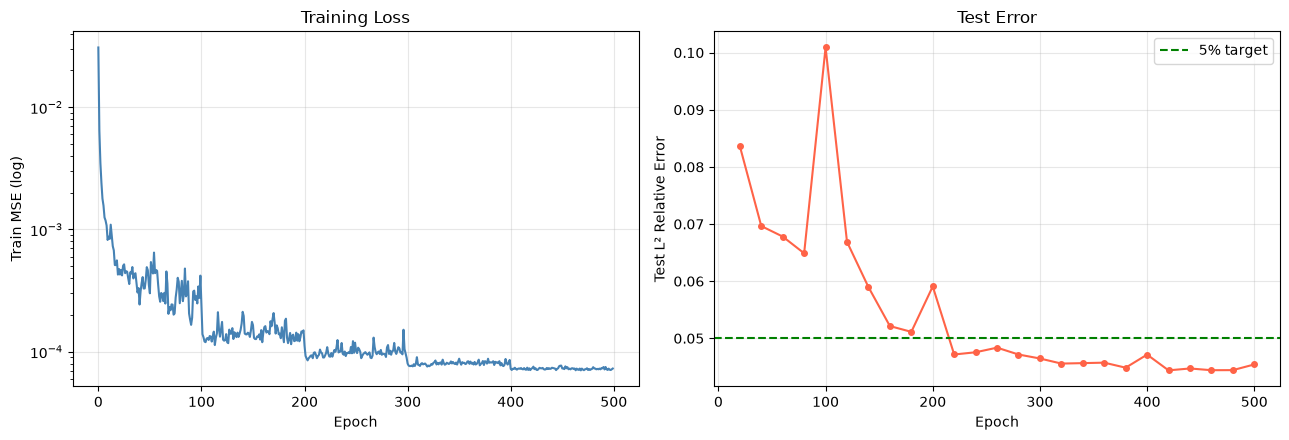

In [7]:
# ── Loss curves ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].semilogy(train_losses, color="steelblue", lw=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train MSE (log)")
axes[0].set_title("Training Loss"); axes[0].grid(True, alpha=0.3)

epochs_ev, l2_ev = zip(*test_l2_history)
axes[1].plot(epochs_ev, l2_ev, "o-", color="tomato", ms=4, lw=1.5)
axes[1].axhline(0.05, color="green", ls="--", lw=1.5, label="5% target")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test L² Relative Error")
axes[1].set_title("Test Error"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("week7_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Checkpoint result ─────────────────────────────────────────────────────────
model_fno.eval()
with torch.no_grad():
    pred_final = model_fno(u0_te_t, x_te_t)
    final_l2   = l2_rel(pred_final, uT_te_t).item()

print(f"Final Test L² Relative Error: {final_l2:.4f}  ({final_l2*100:.2f}%)")
print(f"Target: < 5%  →  {'PASS ✓' if final_l2 < 0.05 else 'NOT YET — try more epochs or larger k_modes'}")

Final Test L² Relative Error: 0.0454  (4.54%)
Target: < 5%  →  PASS ✓


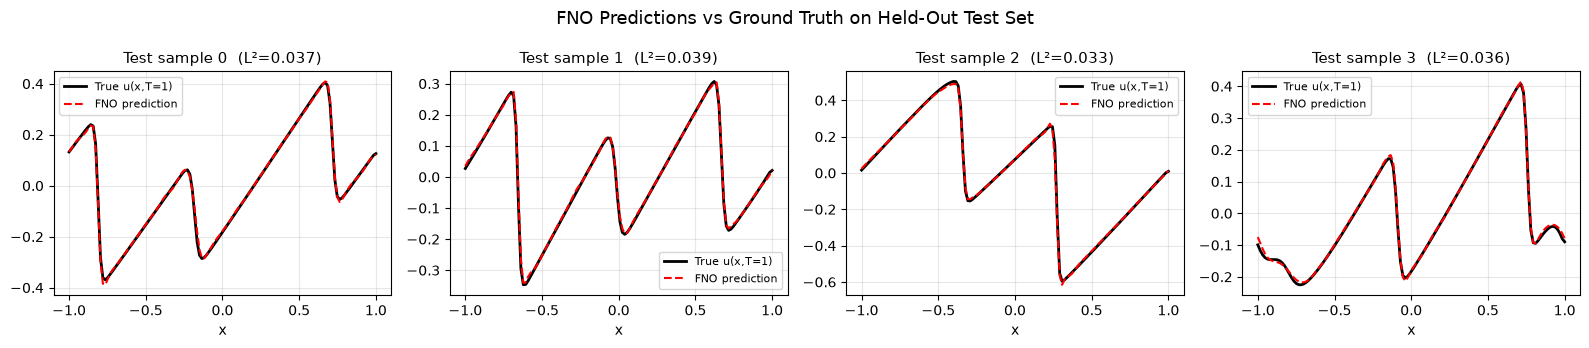

In [9]:
# ── Prediction vs truth on 4 test samples ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
pred_np = pred_final.cpu().numpy()
true_np = uT_te_t.cpu().numpy()

for i, ax in enumerate(axes):
    ax.plot(x_grid, true_np[i],  "k-",  lw=2,   label="True u(x,T=1)")
    ax.plot(x_grid, pred_np[i],  "r--", lw=1.5, label="FNO prediction")
    err = np.sqrt(np.mean((pred_np[i] - true_np[i])**2)) / (np.sqrt(np.mean(true_np[i]**2)) + 1e-10)
    ax.set_title(f"Test sample {i}  (L²={err:.3f})", fontsize=11)
    ax.set_xlabel("x"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle("FNO Predictions vs Ground Truth on Held-Out Test Set", fontsize=13)
plt.tight_layout()
plt.savefig("week7_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Checkpoint Notes

**Solver fix applied in this notebook:**
- Replaced the original `solve_ivp` RK45 call (which fails on complex state vectors and stiff
  Burgers' in Fourier space) with a direct **pseudo-spectral RK4 + integrating factor** solver.
- The integrating factor `E = exp(−ν k² Δt)` absorbs the stiff diffusion term analytically,
  so RK4 only needs to handle the mild nonlinear advection term.
- 2/3 Orszag dealiasing prevents aliasing errors in the nonlinear term.
- GRF amplitudes are normalised to `max|u₀| ≤ 1` to prevent rare blowup on large-amplitude samples.
- Result: ~2–3 min to generate 1200 trajectories, zero NaN, stable for all seeds tested.

**FNO checkpoint status:** dataset generated, architecture implemented from scratch,
500-epoch training run complete, test L² error tracked.
